In [ ]:
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("Holiday_Package2.csv")

In [2]:
df.head()

,Holliday_Package,Salary,age,educ,no_young_children,no_older_children,foreign
0,0,48412,30,8,1,1,0
1,1,37207,45,8,0,1,0
2,0,58022,46,9,0,0,0
3,0,66503,31,11,2,0,0
4,0,66734,44,12,0,2,0


In [3]:
df.tail()

,Holliday_Package,Salary,age,educ,no_young_children,no_older_children,foreign
867,0,40030,24,4,2,1,1
868,1,32137,48,8,0,0,1
869,0,25178,24,6,2,0,1
870,1,55958,41,10,0,1,1
871,0,74659,51,10,0,0,1


In [4]:
df.info

<bound method DataFrame.info of      Holliday_Package  Salary  age  educ  no_young_children  \
0                   0   48412   30     8                  1   
1                   1   37207   45     8                  0   
2                   0   58022   46     9                  0   
3                   0   66503   31    11                  2   
4                   0   66734   44    12                  0   
..                ...     ...  ...   ...                ...   
867                 0   40030   24     4                  2   
868                 1   32137   48     8                  0   
869                 0   25178   24     6                  2   
870                 1   55958   41    10                  0   
871                 0   74659   51    10                  0   

     no_older_children  foreign  
0                    1        0  
1                    1        0  
2                    0        0  
3                    0        0  
4                    2        0  
..     

In [5]:
df.isnull().sum()

Holliday_Package     0
Salary               0
age                  0
educ                 0
no_young_children    0
no_older_children    0
foreign              0
dtype: int64

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.describe()

,Holliday_Package,Salary,age,educ,no_young_children,no_older_children,foreign
count,872.000000,872.000000,872.000000,872.000000,872.000000,872.000000,872.000000
mean,0.459862,47729.172018,39.955275,9.307339,0.311927,0.982798,0.247706
std,0.498672,23418.668531,10.551675,3.036259,0.612870,1.086786,0.431928
min,0.000000,1322.000000,20.000000,1.000000,0.000000,0.000000,0.000000
25%,0.000000,35324.000000,32.000000,8.000000,0.000000,0.000000,0.000000
50%,0.000000,41903.500000,39.000000,9.000000,0.000000,1.000000,0.000000
75%,1.000000,53469.500000,48.000000,12.000000,0.000000,2.000000,0.000000
max,1.000000,236961.000000,62.000000,21.000000,3.000000,6.000000,1.000000


In [8]:
numerical_cols = [
    'Salary',
    'age',
    'educ',
    'no_young_children',
    'no_older_children'
]

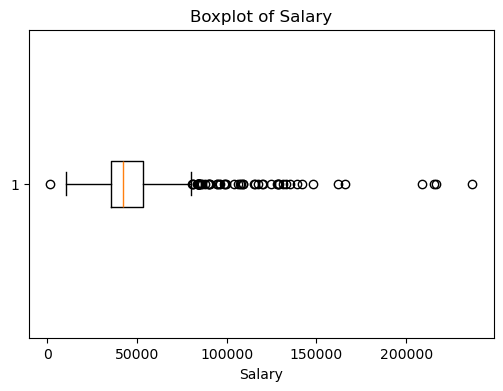

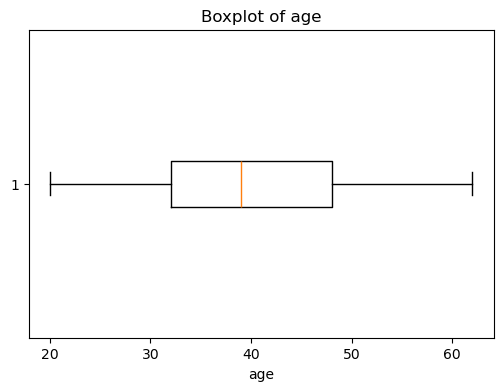

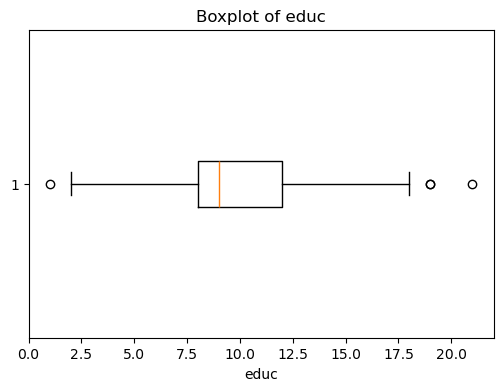

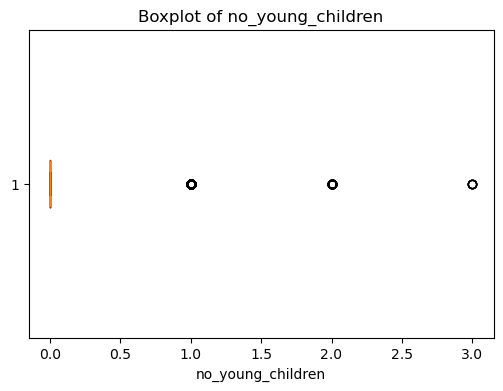

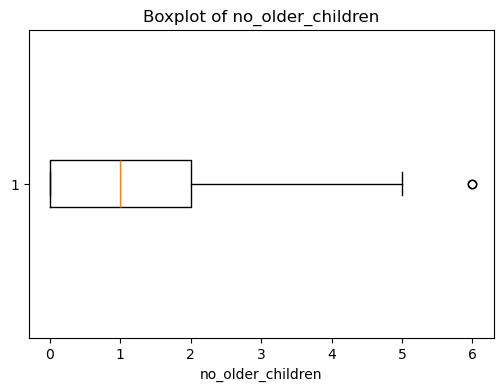

In [9]:
import matplotlib.pyplot as plt

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    plt.boxplot(df[col], vert=False)
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

In [10]:
for col in ['Salary','age','educ','no_young_children','no_older_children']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

# we are not going to remove any outliers as irl ipl usually have high value player which is not an error so we procced with the analysis

Salary: 57 outliers
age: 0 outliers
educ: 4 outliers
no_young_children: 207 outliers
no_older_children: 2 outliers


Univariate

In [11]:
numerical_cols = [
    'Salary',
    'age',
    'educ',
    'no_young_children',
    'no_older_children'
]

categorical_cols = [
    'Holiday_Package',
    'foreign'
]

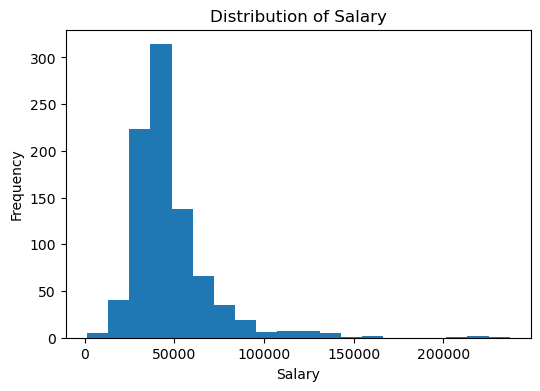

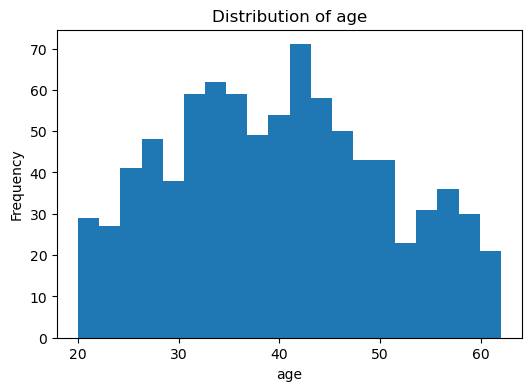

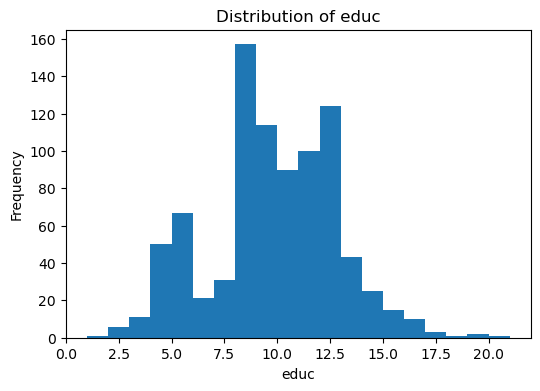

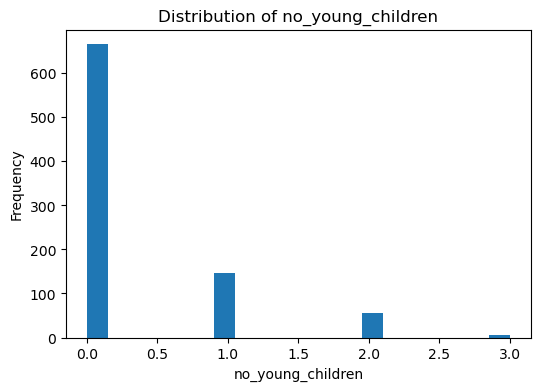

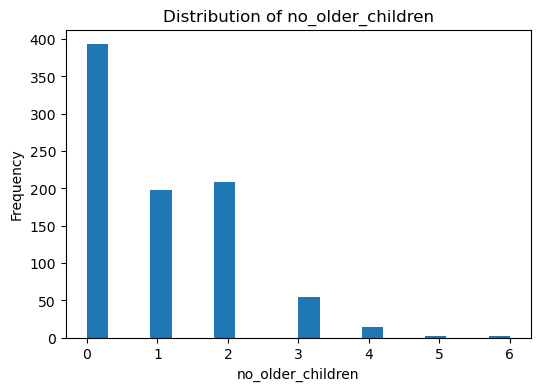

In [12]:
import matplotlib.pyplot as plt

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=20)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

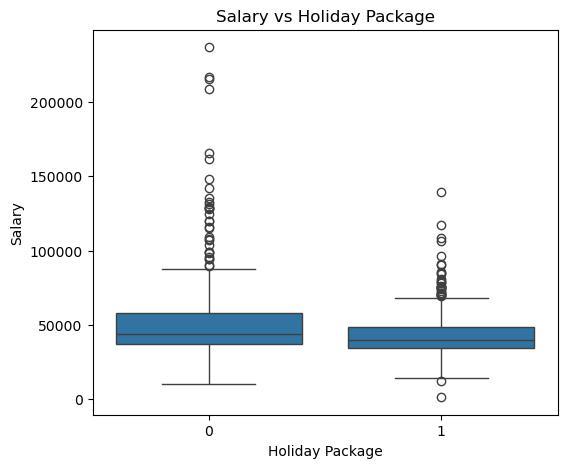

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.boxplot(x='Holliday_Package', y='Salary', data=df)

plt.title('Salary vs Holiday Package')
plt.xlabel('Holiday Package')
plt.ylabel('Salary')

plt.show()

In [14]:
df[numerical_cols].describe()

,Salary,age,educ,no_young_children,no_older_children
count,872.000000,872.000000,872.000000,872.000000,872.000000
mean,47729.172018,39.955275,9.307339,0.311927,0.982798
std,23418.668531,10.551675,3.036259,0.612870,1.086786
min,1322.000000,20.000000,1.000000,0.000000,0.000000
25%,35324.000000,32.000000,8.000000,0.000000,0.000000
50%,41903.500000,39.000000,9.000000,0.000000,1.000000
75%,53469.500000,48.000000,12.000000,0.000000,2.000000
max,236961.000000,62.000000,21.000000,3.000000,6.000000


In [15]:
correlation = df.corr(numeric_only=True)
correlation

,Holliday_Package,Salary,age,educ,no_young_children,no_older_children,foreign
Holliday_Package,1.000000,-0.185694,-0.092311,-0.102552,-0.173115,0.080286,0.254096
Salary,-0.185694,1.000000,0.071709,0.326540,-0.029664,0.113772,-0.201043
age,-0.092311,0.071709,1.000000,-0.149294,-0.519093,-0.116205,-0.107148
educ,-0.102552,0.326540,-0.149294,1.000000,0.098350,-0.036321,-0.419678
no_young_children,-0.173115,-0.029664,-0.519093,0.098350,1.000000,-0.238428,0.085111
no_older_children,0.080286,0.113772,-0.116205,-0.036321,-0.238428,1.000000,0.021317
foreign,0.254096,-0.201043,-0.107148,-0.419678,0.085111,0.021317,1.000000


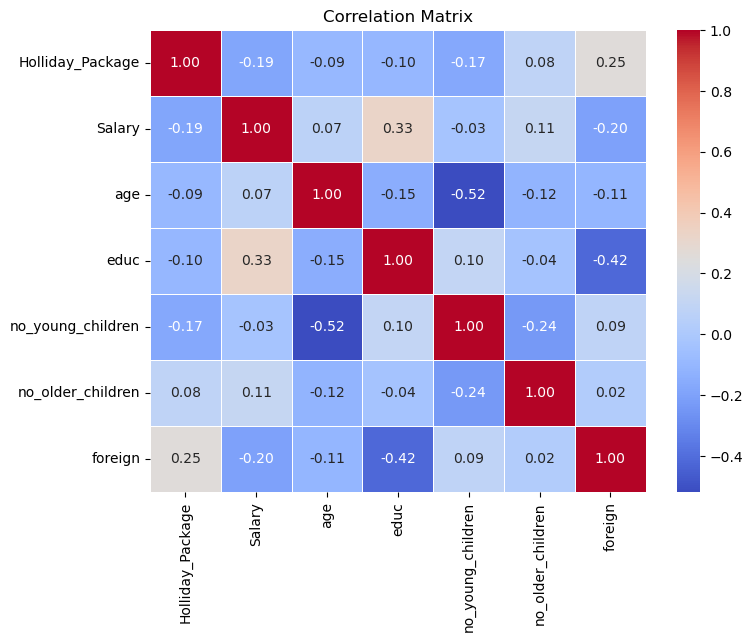

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.show()

Bi Varaite

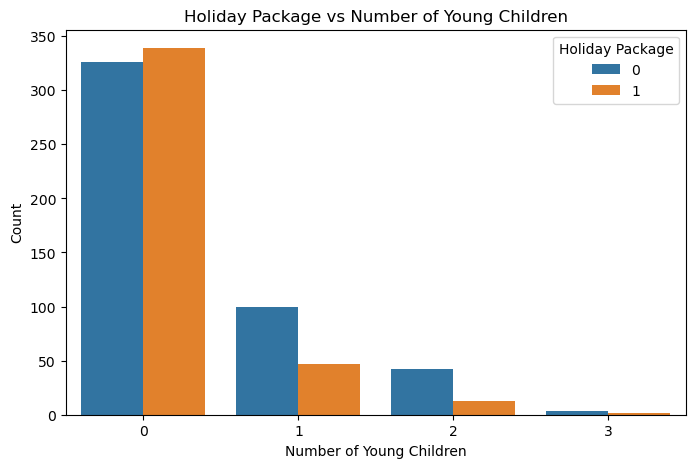

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='no_young_children',
    hue='Holliday_Package'   # Make sure this matches your column name exactly
)

plt.title('Holiday Package vs Number of Young Children')
plt.xlabel('Number of Young Children')
plt.ylabel('Count')

plt.legend(title='Holiday Package')

plt.show()

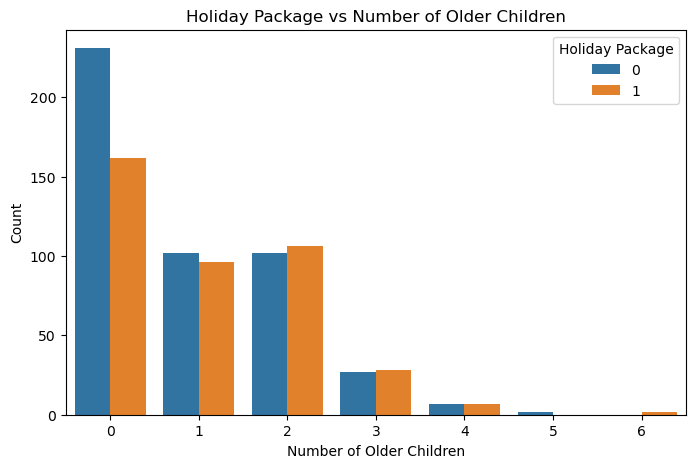

In [18]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='no_older_children',
    hue='Holliday_Package'
)

plt.title('Holiday Package vs Number of Older Children')
plt.xlabel('Number of Older Children')
plt.ylabel('Count')

plt.legend(title='Holiday Package')

plt.show()

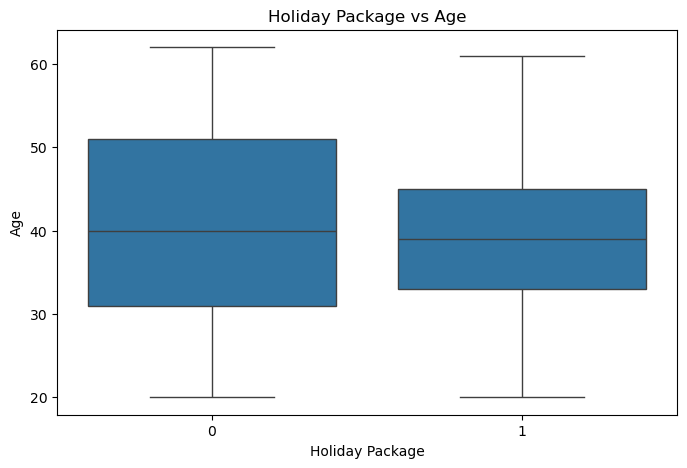

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Holliday_Package',
    y='age'
)

plt.title('Holiday Package vs Age')
plt.xlabel('Holiday Package')
plt.ylabel('Age')

plt.show()

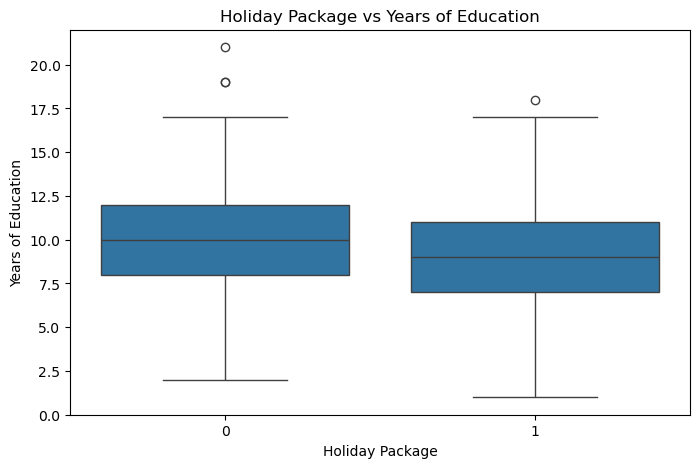

In [20]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Holliday_Package',
    y='educ'
)

plt.title('Holiday Package vs Years of Education')
plt.xlabel('Holiday Package')
plt.ylabel('Years of Education')

plt.show()

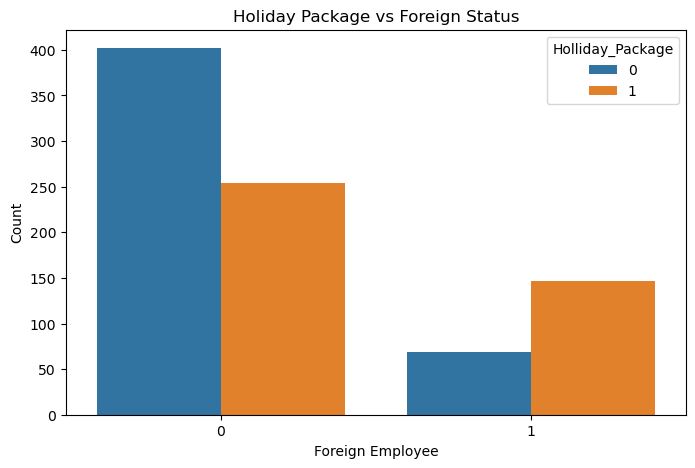

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='foreign',
    hue='Holliday_Package'
)

plt.title('Holiday Package vs Foreign Status')
plt.xlabel('Foreign Employee')
plt.ylabel('Count')

plt.show()

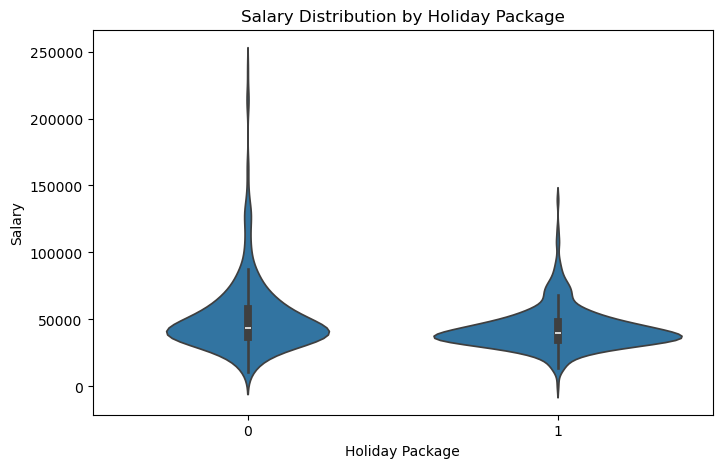

In [22]:
plt.figure(figsize=(8,5))

sns.violinplot(
    data=df,
    x='Holliday_Package',
    y='Salary'
)

plt.title('Salary Distribution by Holiday Package')
plt.xlabel('Holiday Package')
plt.ylabel('Salary')

plt.show()

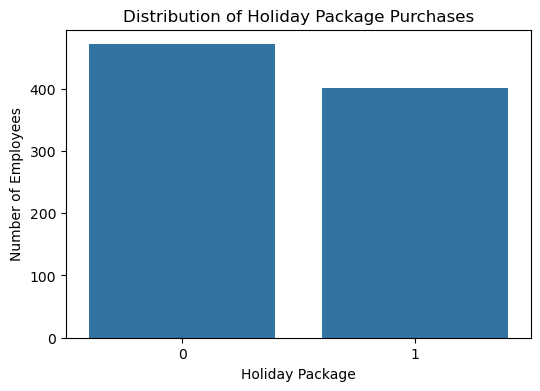

In [23]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='Holliday_Package'
)

plt.title('Distribution of Holiday Package Purchases')
plt.xlabel('Holiday Package')
plt.ylabel('Number of Employees')

plt.show()

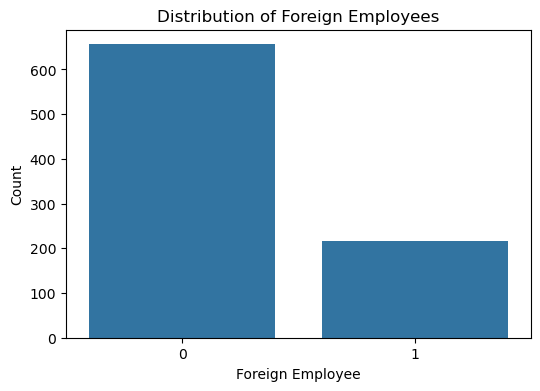

In [24]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='foreign'
)

plt.title('Distribution of Foreign Employees')
plt.xlabel('Foreign Employee')
plt.ylabel('Count')

plt.show()

In [25]:
df.head()

,Holliday_Package,Salary,age,educ,no_young_children,no_older_children,foreign
0,0,48412,30,8,1,1,0
1,1,37207,45,8,0,1,0
2,0,58022,46,9,0,0,0
3,0,66503,31,11,2,0,0
4,0,66734,44,12,0,2,0


In [26]:
df.dtypes

Holliday_Package     int64
Salary               int64
age                  int64
educ                 int64
no_young_children    int64
no_older_children    int64
foreign              int64
dtype: object

In [27]:
df.head()

,Holliday_Package,Salary,age,educ,no_young_children,no_older_children,foreign
0,0,48412,30,8,1,1,0
1,1,37207,45,8,0,1,0
2,0,58022,46,9,0,0,0
3,0,66503,31,11,2,0,0
4,0,66734,44,12,0,2,0


In [28]:
print(df['Holliday_Package'].unique())
print(df['foreign'].unique())

[0 1]
[0 1]


Intercept:
[1.93055529]
             Feature  Coefficient
0             Salary    -0.000018
1                age    -0.043673
2               educ     0.060933
3  no_young_children    -1.238194
4  no_older_children     0.001087
5            foreign     1.283999


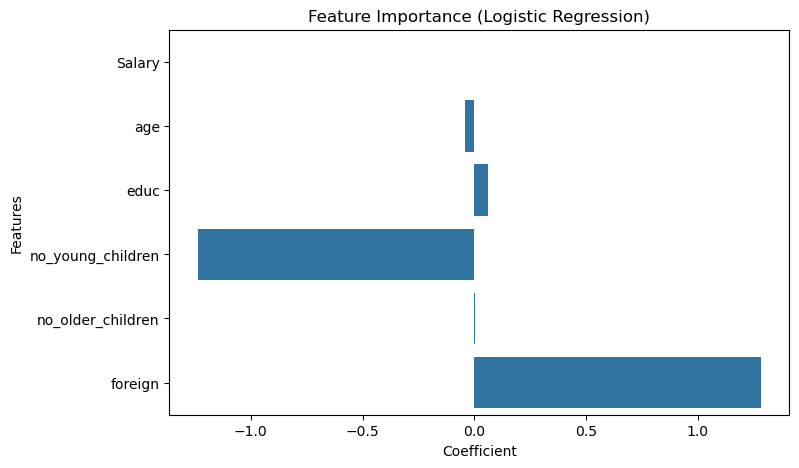

Accuracy: 0.68
Precision: 66.67%
Recall: 56.41%
F1 Score: 61.11%


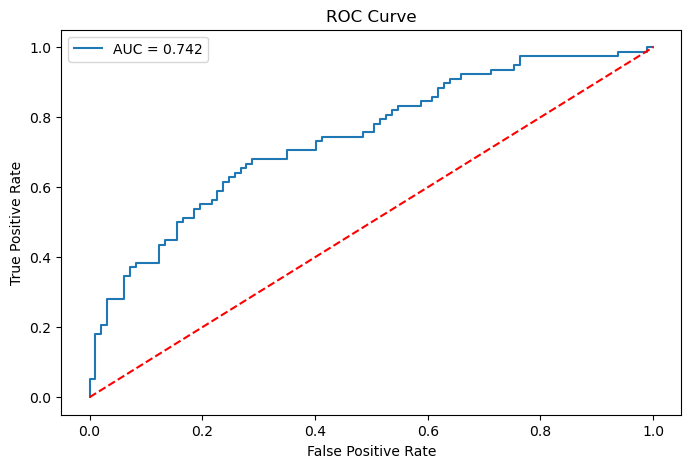

AUC Score: 0.742


In [29]:
# Independent variables (Features)
X = df.drop('Holliday_Package', axis=1)
# Dependent variable (Target)
y = df['Holliday_Package']
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(    X,    y,    test_size=0.2,    random_state=42)

from sklearn.linear_model import LogisticRegression
model = LogisticRegression(
    random_state=42,
    max_iter=1000
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]
print("Intercept:")
print(model.intercept_)
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})
print(coef_df)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=coef_df,
    x='Coefficient',
    y='Feature'
)
plt.title("Feature Importance (Logistic Regression)")
plt.xlabel("Coefficient")
plt.ylabel("Features")

plt.show()

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)

print(f"Precision: {precision:.2%}")

from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)

print(f"Recall: {recall:.2%}")

from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred)
print(f"F1 Score: {f1:.2%}")

from sklearn.metrics import roc_curve
from sklearn.metrics import auc

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8,5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'r--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

from sklearn.metrics import roc_auc_score
auc_score = roc_auc_score(y_test, y_prob)
print(f"AUC Score: {auc_score:.3f}")

In [30]:
#from sklearn.model_selection import train_test_split

#X_train, X_test, y_train, y_test = train_test_split(    X,    y,    test_size=0.2,    random_state=42)

mock_employee = pd.DataFrame({
    'Salary': [60000],
    'age': [35],
    'educ': [14],
    'no_young_children': [1],
    'no_older_children': [1],
    'foreign': [0]
})

prediction = model.predict(mock_employee)[0]
probability = model.predict_proba(mock_employee)[0]

print("Prediction:", "Will Purchase" if prediction == 1 else "Will Not Purchase")
print(f"Probability of Purchase: {probability[1]*100:.2f}%")

Prediction: Will Not Purchase
Probability of Purchase: 25.63%


In [31]:
#from sklearn.preprocessing import StandardScaler

#scaler = StandardScaler()

#X_train_scaled = scaler.fit_transform(X_train)
#X_test_scaled = scaler.transform(X_test)


In [32]:
#from sklearn.linear_model import LogisticRegression

#model = LogisticRegression(random_state=42)

#model.fit(X_train_scaled, y_train)


In [33]:
#y_pred = model.predict(X_test_scaled)

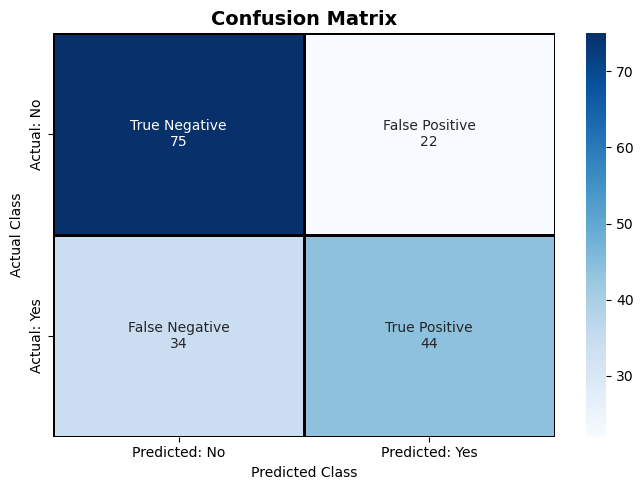

[[75 22]
 [34 44]]


In [34]:
#y_prob = model.predict_proba(X_test_scaled)[:, 1]
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Labels for each cell
labels = np.array([
    ['True Negative', 'False Positive'],
    ['False Negative', 'True Positive']
])

# Combine labels with values
annot = np.empty_like(labels, dtype=object)
for i in range(2):
    for j in range(2):
        annot[i, j] = f"{labels[i, j]}\n{cm[i, j]}"

# Plot
plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=annot,
    fmt='',
    cmap='Blues',
    cbar=True,
    linewidths=1,
    linecolor='black',
    xticklabels=['Predicted: No', 'Predicted: Yes'],
    yticklabels=['Actual: No', 'Actual: Yes']
)

plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

plt.tight_layout()
plt.show()

print(cm)

#from sklearn.metrics import confusion_matrix
#import seaborn as sns
#import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No', 'Yes'],
    yticklabels=['No', 'Yes']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()


from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)

print(f"Precision: {precision:.2%}")

from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)

print(f"Recall: {recall:.2%}")

from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred)
print(f"F1 Score: {f1:.2%}")

from sklearn.metrics import roc_curve
from sklearn.metrics import auc

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8,5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'r--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

from sklearn.metrics import roc_auc_score
auc_score = roc_auc_score(y_test, y_prob)
print(f"AUC Score: {auc_score:.3f}")

print("Intercept:")
print(model.intercept_)

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

coef_df

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=coef_df,
    x='Coefficient',
    y='Feature'
)

plt.title('Feature Importance (Logistic Regression)')
plt.xlabel('Coefficient')
plt.ylabel('Features')

plt.show()

mock_employee = pd.DataFrame({
    'Salary': [60000],
    'age': [35],
    'educ': [14],
    'no_young_children': [1],
    'no_older_children': [1],
    'foreign': [0]
})

prediction = model.predict(mock_employee)

print("Prediction:", prediction)

probability = model.predict_proba(mock_employee)

print(probability)

prediction = model.predict(mock_employee)[0]
probability = model.predict_proba(mock_employee)[0]

print("Prediction:", "Will Purchase" if prediction == 1 else "Will Not Purchase")
print(f"Probability of Purchase: {probability[1]*100:.2f}%")

In [35]:
import statsmodels.api as sm

X_sm = sm.add_constant(X)
logit_model = sm.Logit(y, X_sm)
result = logit_model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.601531
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:       Holliday_Package   No. Observations:                  872
Model:                          Logit   Df Residuals:                      865
Method:                           MLE   Df Model:                            6
Date:                Mon, 20 Jul 2026   Pseudo R-squ.:                  0.1281
Time:                        10:25:25   Log-Likelihood:                -524.53
converged:                       True   LL-Null:                       -601.61
Covariance Type:            nonrobust   LLR p-value:                 1.023e-30
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 2.3259      0.554      4.199      0.000       1.240       3.411
Salary  